# Lecture 5 companion 3 · RMSProp, Adam, schedules, and constraints

We continue with the **same four-example ravine** from the momentum notebook. For every method, we follow one sequence: **problem → intuition → state → update rule → computed outcome → PyTorch check**.

- RMSProp remembers squared gradients to rescale coordinates.
- Adam combines first-moment direction memory with second-moment scaling.
- Learning-rate schedules scale any optimizer's proposed direction; decay reduces late stochastic wandering.
- Reparameterization or projection keeps constrained parameters feasible.

> Keep asking: what information does the new state remember, and how does that memory repair the failure we just observed?

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

SEED = 12
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
INK, BLUE, TEAL, GREEN, ORANGE, RED, PURPLE = ('#23373B','#2B6CB0','#2C7A7B','#14A66A','#EB811B','#D64550','#7B61A8')
plt.rcParams.update({'figure.figsize': (7.2, 3.4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': .18})

X = np.array([[-1.,-10.],[-1.,10.],[1.,-10.],[1.,10.]])
theta_star = np.array([1., -.5])
y = X @ theta_star
theta0 = np.array([-1.4, .35])

def ravine_loss(theta): return 0.5*np.mean((X@theta-y)**2)
def ravine_grad(theta): return X.T@(X@theta-y)/len(X)

theta1_grid, theta2_grid = np.linspace(-1.65,1.45,260), np.linspace(-1.52,.52,260)
THETA1, THETA2 = np.meshgrid(theta1_grid, theta2_grid)
LGRID = .5*(THETA1-theta_star[0])**2 + 50*(THETA2-theta_star[1])**2
LEVELS = [.05,.15,.4,.9,1.8,3.5,7,14,25,40]
assert np.allclose(X.T@X/len(X), np.diag([1.,100.]))
assert np.allclose(ravine_grad(theta0), [-2.4, 85.])
assert np.isclose(ravine_loss(theta0), 39.005)

## 1. RMSProp: measure a recent scale for each coordinate

### The limitation left after momentum

Momentum combines gradients across updates, but its final move still uses one global learning rate. In Example B,

$$
\boldsymbol g(\boldsymbol\theta)
=\big(\theta_1-1,\ 100(\theta_2+0.5)\big).
$$

At the common start,

$$
\boldsymbol\theta_0=(-1.4,0.35),\qquad
\boldsymbol g_0=(-2.4,85),\qquad
\frac{|g_{0,2}|}{|g_{0,1}|}=35.4.
$$

Multiplying both components by the same $\eta$ preserves this imbalance. RMSProp adds one recent scale per coordinate:

1. **measure** the current gradient;
2. **square** each component so positive and negative gradients both count as large;
3. **average** those squares over time;
4. take the **root** and divide by it before moving.

`RMS` is the **root mean square** in steps 2–4. The optimizer name is commonly expanded as *root mean square propagation*; the computation to remember is that the running RMS rescales the proposed update.


In [2]:
def gd_step(theta, gradient, eta):
    # One vectorized gradient-descent update.
    return theta - eta * gradient


def rmsprop_step(theta, gradient, v, eta, beta2=.9, eps=1e-8):
    # One vectorized RMSProp update; all operations are elementwise.
    v_next = beta2 * v + (1 - beta2) * gradient**2
    rms_scale = np.sqrt(v_next) + eps
    theta_next = theta - eta * gradient / rms_scale
    return theta_next, v_next, rms_scale


g0 = ravine_grad(theta0)
print('plain GD multiplies both coordinates by the same eta:')
print('g_0 =', g0, ' -> with eta=.0195, delta theta =', -.0195 * g0)
assert np.allclose(g0, [-2.4, 85.])


plain GD multiplies both coordinates by the same eta:
g_0 = [-2.4 85. ]  -> with eta=.0195, delta theta = [ 0.0468 -1.6575]


### The state and update rule

Use $\boldsymbol v_t$ for the running mean of squared gradients and initialize

$$\boldsymbol v_0=\boldsymbol 0.$$

At update $t+1$:

$$
\begin{aligned}
\text{measure:}\quad &\widehat{\boldsymbol g}_t=\nabla_{\boldsymbol\theta}\mathcal L_{\mathcal B_t}(\boldsymbol\theta_t),\\
\text{remember squares:}\quad
&\boldsymbol v_{t+1}=\beta_2\boldsymbol v_t+(1-\beta_2)\widehat{\boldsymbol g}_t^{\odot 2},\\
\text{build RMS scales:}\quad
&\boldsymbol r_{t+1}=\sqrt{\boldsymbol v_{t+1}}+\varepsilon_{\mathrm{opt}},\\
\text{rescale and move:}\quad
&\boldsymbol\theta_{t+1}
=\boldsymbol\theta_t-\eta\frac{\widehat{\boldsymbol g}_t}{\boldsymbol r_{t+1}}.
\end{aligned}
$$

$\widehat{\boldsymbol g}_t$ is the gradient supplied by the current batch; for full-batch Example B, $\widehat{\boldsymbol g}_t=\boldsymbol g_t$. Every multiplication, square, root, and division is elementwise. A history of large gradients creates a large denominator and therefore a smaller move in that coordinate. We use $\boldsymbol v_t$ for this squared-gradient memory in both RMSProp and Adam. PyTorch stores it under its internal name `square_avg`.


### One scalar loss: compare the first update

Use the same loss and current gradient for all three methods:

$$\mathcal L(\theta)=\tfrac12\theta^2,\qquad \theta_0=2,\qquad g_0=\left.\frac{d\mathcal L}{d\theta}\right|_{\theta=2}=2.$$

Initialize $m_0=v_0=0$ and use $\eta=.10$, $\beta=.5$, $\beta_2=.9$, and $\varepsilon_{\mathrm{opt}}=0$ for this formula check.

- **Plain GD:** $\theta_1=2-.10(2)=1.80$, so $\mathcal L_1=\tfrac12(1.80)^2=1.620$.
- **Momentum:** $m_1=.5(0)+.5(2)=1$ and $\theta_1=2-.10(1)=1.90$, so $\mathcal L_1=1.805$.
- **RMSProp:** $v_1=.9(0)+.1(2^2)=.4$, $r_1=\sqrt{.4}=.632$, and $g_0/r_1=3.162$. Hence $\theta_1=2-.10(3.162)=1.684$ and $\mathcal L_1\approx1.418$.

GD uses the current gradient; momentum first forms a signed running average; RMSProp first divides the gradient by its recent root-mean-square scale. This single update checks the formulas—it is not an optimizer ranking.


In [3]:
theta_toy, eta_toy = 2.0, 0.10
g_toy = theta_toy                   # d(0.5 theta^2) / d theta
beta_toy, beta2_toy = 0.5, 0.9
m0_toy, v0_toy = 0.0, 0.0

theta_gd = theta_toy - eta_toy * g_toy

m1_toy = beta_toy * m0_toy + (1 - beta_toy) * g_toy
theta_momentum = theta_toy - eta_toy * m1_toy

v1_toy = beta2_toy * v0_toy + (1 - beta2_toy) * g_toy**2
r1_toy = np.sqrt(v1_toy)            # epsilon_opt = 0 for this hand check
theta_rmsprop = theta_toy - eta_toy * g_toy / r1_toy

loss_toy = lambda theta: 0.5 * theta**2
print(f'GD:       theta_1={theta_gd:.3f}, loss_1={loss_toy(theta_gd):.3f}')
print(f'Momentum: theta_1={theta_momentum:.3f}, loss_1={loss_toy(theta_momentum):.3f}, m_1={m1_toy:.3f}')
print(f'RMSProp:  theta_1={theta_rmsprop:.3f}, loss_1={loss_toy(theta_rmsprop):.3f}, v_1={v1_toy:.3f}, r_1={r1_toy:.3f}, g_0/r_1={g_toy/r1_toy:.3f}')

assert np.isclose(theta_gd, 1.8)
assert np.isclose(theta_momentum, 1.9)
assert np.isclose(theta_rmsprop, 1.683772233983162)


GD:       theta_1=1.800, loss_1=1.620
Momentum: theta_1=1.900, loss_1=1.805, m_1=1.000
RMSProp:  theta_1=1.684, loss_1=1.418, v_1=0.400, r_1=0.632, g_0/r_1=3.162


In [4]:
beta2_rms, eta_rms, eps = .9, .08, 1e-8

# Update 1: v_0 is zero, so only g_0 enters the first memory.
v0_rms = np.zeros_like(theta0)
g0 = ravine_grad(theta0)
theta1_rms, v1_rms, rms1 = rmsprop_step(theta0, g0, v0_rms, eta_rms, beta2_rms, eps)
scaled_g0 = g0 / rms1

print('INITIAL CONDITION')
print('theta_0 =', theta0, '  v_0 =', v0_rms)
print('\nUPDATE 1: build scales, divide, then move')
print('g_0                     =', np.round(g0, 6))
print('v_1=.9 v_0+.1 g_0^2    =', np.round(v1_rms, 6))
print('r_1=sqrt(v_1)+eps       =', np.round(rms1, 6))
print('g_0/r_1                 =', np.round(scaled_g0, 6))
print('theta_1                 =', np.round(theta1_rms, 6))

# Update 2: the new squares are blended with the history already in v_1.
g1 = ravine_grad(theta1_rms)
theta2_rms, v2_rms, rms2 = rmsprop_step(theta1_rms, g1, v1_rms, eta_rms, beta2_rms, eps)
scaled_g1 = g1 / rms2

print('\nUPDATE 2: v_1 is retained and the new g_1^2 is added')
print('g_1                     =', np.round(g1, 6))
print('v_2=.9 v_1+.1 g_1^2    =', np.round(v2_rms, 6))
print('r_2=sqrt(v_2)+eps       =', np.round(rms2, 6))
print('g_1/r_2                 =', np.round(scaled_g1, 6))
print('theta_2                 =', np.round(theta2_rms, 6))

# A compact state table makes the recurrence visible beyond the first two updates.
theta, v = theta0.copy(), np.zeros_like(theta0)
rows = [(0, *theta, np.nan, np.nan, 0., 0., ravine_loss(theta))]
for update in range(1, 6):
    gradient = ravine_grad(theta)
    theta, v, rms_scale = rmsprop_step(
        theta, gradient, v, eta_rms, beta2_rms, eps)
    rows.append((update, *theta, *gradient, *rms_scale, ravine_loss(theta)))

print('\nRMSPROP STATE AFTER EACH UPDATE')
print(' k |   theta_1   theta_2 |    g_used_1  g_used_2 | RMS_1   RMS_2 | full loss')
for k, th1, th2, gg1, gg2, rr1, rr2, loss in rows:
    if k == 0:
        print(f'{k:2d} | {th1:9.4f} {th2:9.4f} | {"--":>11} {"--":>9} | {rr1:5.3f} {rr2:7.3f} | {loss:9.4f}')
    else:
        print(f'{k:2d} | {th1:9.4f} {th2:9.4f} | {gg1:11.4f} {gg2:9.4f} | {rr1:5.3f} {rr2:7.3f} | {loss:9.4f}')

assert np.allclose(v1_rms, [.576, 722.5])
assert np.allclose(theta1_rms, [-1.14701779, .09701779], atol=1e-8)
assert np.allclose(v2_rms, [.979368539, 1006.68024], atol=1e-5)
assert np.allclose(theta2_rms, [-.97345663, -.05351513], atol=1e-8)


INITIAL CONDITION
theta_0 = [-1.4   0.35]   v_0 = [0. 0.]

UPDATE 1: build scales, divide, then move
g_0                     = [-2.4 85. ]
v_1=.9 v_0+.1 g_0^2    = [5.760e-01 7.225e+02]
r_1=sqrt(v_1)+eps       = [ 0.758947 26.87936 ]
g_0/r_1                 = [-3.162278  3.162278]
theta_1                 = [-1.147018  0.097018]

UPDATE 2: v_1 is retained and the new g_1^2 is added
g_1                     = [-2.147018 59.701779]
v_2=.9 v_1+.1 g_1^2    = [9.79369000e-01 1.00668024e+03]
r_2=sqrt(v_2)+eps       = [ 0.989631 31.728225]
g_1/r_2                 = [-2.169515  1.881661]
theta_2                 = [-0.973457 -0.053515]

RMSPROP STATE AFTER EACH UPDATE
 k |   theta_1   theta_2 |    g_used_1  g_used_2 | RMS_1   RMS_2 | full loss
 0 |   -1.4000    0.3500 |          --        -- | 0.000   0.000 |   39.0050
 1 |   -1.1470    0.0970 |     -2.4000   85.0000 | 0.759  26.879 |   20.1264
 2 |   -0.9735   -0.0535 |     -2.1470   59.7018 | 0.990  31.728 |   11.9147
 3 |   -0.8334   -0.1609 |

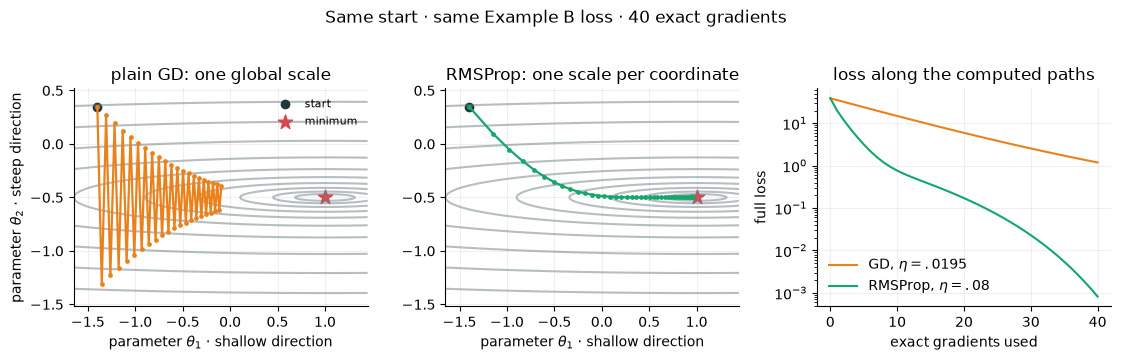

GD:      loss=1.192555 | raw flips=40 | material crossings=40
RMSProp: loss=0.000815 | raw flips= 4 | material crossings= 0
Material crossings ignore numerical sign flips once both adjacent errors are at most 1e-6.


In [5]:
def rmsprop_trace(eta=.08, beta2=.9, steps=55, eps=1e-8):
    theta, v = theta0.copy(), np.zeros_like(theta0)
    path, v_history = [theta.copy()], [v.copy()]
    for _ in range(steps):
        gradient = ravine_grad(theta)
        theta, v, _ = rmsprop_step(
            theta, gradient, v, eta, beta2, eps)
        path.append(theta.copy())
        v_history.append(v.copy())
    return np.asarray(path), np.asarray(v_history)


def rmsprop_path(eta=.08, beta2=.9, steps=55, eps=1e-8):
    return rmsprop_trace(eta, beta2, steps, eps)[0]


def gd_path(eta=.0195, steps=55):
    theta, path = theta0.copy(), [theta0.copy()]
    for _ in range(steps):
        theta = gd_step(theta, ravine_grad(theta), eta)
        path.append(theta.copy())
    return np.asarray(path)


def raw_crossings(path):
    error = np.asarray(path)[:, 1] - theta_star[1]
    return int(np.sum(np.signbit(error[:-1]) != np.signbit(error[1:])))


def material_crossings(path, tolerance=1e-6):
    # Count sign flips only while at least one adjacent error exceeds tolerance.
    error = np.asarray(path)[:, 1] - theta_star[1]
    changed_sign = np.signbit(error[:-1]) != np.signbit(error[1:])
    adjacent_scale = np.maximum(np.abs(error[:-1]), np.abs(error[1:]))
    return int(np.sum(changed_sign & (adjacent_scale > tolerance)))


# Both methods receive 40 exact full-batch gradients.
plain = gd_path(steps=40)
rms, rms_scales = rmsprop_trace(steps=40)
plain_losses = np.array([ravine_loss(theta) for theta in plain])
rms_losses = np.array([ravine_loss(theta) for theta in rms])

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.45))
for ax, path_now, title, color in [
    (axes[0], plain, 'plain GD: one global scale', ORANGE),
    (axes[1], rms, 'RMSProp: one scale per coordinate', GREEN),
]:
    ax.contour(THETA1, THETA2, LGRID, levels=LEVELS, colors='#6E7F82', alpha=.5)
    ax.plot(path_now[:, 0], path_now[:, 1], 'o-', ms=2.4, lw=1.6, color=color)
    ax.scatter(*theta0, color=INK, label='start')
    ax.scatter(*theta_star, marker='*', s=115, color=RED, label='minimum')
    ax.set(title=title, xlabel='parameter $\\theta_1$ · shallow direction',
           xlim=(-1.65, 1.45), ylim=(-1.52, .52))
axes[0].set_ylabel('parameter $\\theta_2$ · steep direction')
axes[0].legend(frameon=False, fontsize=8)
axes[2].semilogy(plain_losses, color=ORANGE, label='GD, $\\eta=.0195$')
axes[2].semilogy(rms_losses, color=GREEN, label='RMSProp, $\\eta=.08$')
axes[2].set(xlabel='exact gradients used', ylabel='full loss', title='loss along the computed paths')
axes[2].legend(frameon=False)
plt.suptitle('Same start · same Example B loss · 40 exact gradients', y=1.03)
plt.tight_layout(); plt.show()

print(f'GD:      loss={plain_losses[-1]:.6f} | raw flips={raw_crossings(plain):2d} | material crossings={material_crossings(plain):2d}')
print(f'RMSProp: loss={rms_losses[-1]:.6f} | raw flips={raw_crossings(rms):2d} | material crossings={material_crossings(rms):2d}')
print('Material crossings ignore numerical sign flips once both adjacent errors are at most 1e-6.')

assert np.isclose(plain_losses[-1], 1.1925548690816137)
assert np.isclose(rms_losses[-1], 0.0008152220927773294)
assert (raw_crossings(plain), raw_crossings(rms)) == (40, 4)
assert (material_crossings(plain), material_crossings(rms)) == (40, 0)


### Mapping the recurrence to PyTorch

After deriving and executing the vectorized update, the framework names are straightforward:

- the lecture calls the retention coefficient $\beta_2$; PyTorch names the same argument `alpha`, so use `alpha=beta2_rms`;
- `state['square_avg']` is our $\boldsymbol v_t$;
- `eps` is added after the square root in this simplest RMSProp form.

The check below compares every parameter vector and every PyTorch `square_avg` state with the $\boldsymbol v_t$ history from our NumPy recurrence using float64.


In [6]:
steps = 15
numpy_rms, numpy_v = rmsprop_trace(eta_rms, beta2_rms, steps, eps)
Xt = torch.tensor(X, dtype=torch.float64)
yt = torch.tensor(y, dtype=torch.float64)
theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
opt = torch.optim.RMSprop(
    [theta_param], lr=eta_rms, alpha=beta2_rms, eps=eps,
    momentum=0, centered=False, weight_decay=0)

torch_rms = [theta_param.detach().numpy().copy()]
torch_v = [np.zeros_like(theta0)]
for _ in range(steps):
    opt.zero_grad(set_to_none=True)
    objective = .5 * ((Xt @ theta_param - yt)**2).mean()
    objective.backward()
    opt.step()
    torch_rms.append(theta_param.detach().numpy().copy())
    torch_v.append(opt.state[theta_param]['square_avg'].detach().numpy().copy())

torch_rms, torch_v = np.asarray(torch_rms), np.asarray(torch_v)
print('first PyTorch square_avg state (= v_1):', torch_v[1])
print(f'maximum parameter-path difference: {np.max(np.abs(torch_rms-numpy_rms)):.3e}')
print(f'maximum v-state difference:        {np.max(np.abs(torch_v-numpy_v)):.3e}')

assert np.allclose(torch_rms, numpy_rms, atol=1e-12)
assert np.allclose(torch_v, numpy_v, atol=1e-12)
assert np.allclose(torch_v[1], [.576, 722.5])


first PyTorch square_avg state (= v_1): [5.760e-01 7.225e+02]
maximum parameter-path difference: 1.943e-16
maximum v-state difference:        1.137e-13


## 2. Adam: estimate two moments, then combine them

Momentum and RMSProp store different summaries of the same gradient sequence:

- the **first raw moment** is the mean of $\boldsymbol g$; its signed EWMA remembers direction;
- the **second raw moment** is the mean of $\boldsymbol g^{\odot 2}$; its EWMA measures coordinate scale.

When Adam combines the two memories, standalone momentum's $\beta$ is renamed $\beta_1$ for the signed-gradient EWMA; RMSProp's $\beta_2$ carries over for the squared-gradient EWMA. The subscripts label the two roles, not equal numerical settings.

Adam means **adaptive moment estimation**. It keeps both running estimates:

$$
\boldsymbol m_{t+1}=\beta_1\boldsymbol m_t+(1-\beta_1)\widehat{\boldsymbol g}_t,
\qquad \boldsymbol m_0=\boldsymbol 0,
$$

$$
\boldsymbol v_{t+1}=\beta_2\boldsymbol v_t+(1-\beta_2)\widehat{\boldsymbol g}_t^{\odot 2},
\qquad \boldsymbol v_0=\boldsymbol 0.
$$

At update $t$, $\widehat{\boldsymbol g}_t$ is measured at $\boldsymbol\theta_t$; in our full-batch worked example it equals the exact $\boldsymbol g_t$. The new states $\boldsymbol m_{t+1}$ and $\boldsymbol v_{t+1}$ then determine the move to $\boldsymbol\theta_{t+1}$. The first state supplies signed direction; the square root of the second supplies one recent RMS scale per coordinate.

Both memories start at zero, so their early values contain less than one unit of EWMA weight. The temperature example makes that startup effect concrete; next we reuse the same calculation before forming Adam's update.


### From temperature smoothing to Adam's two corrections

First return to the actual temperature sequence. Its first reading is $x_1=17.9681$ degrees C. With $\beta=.9$ and a zero start $m_0=0$, the raw first memory is only

$$m_1=.9m_0+.1x_1=1.79681.$$

Only $.1$ total weight has entered, so dividing by that accumulated mass recovers the scale of the observation: $\widehat m_1=1.79681/(1-.9)=17.9681$. The temperature plots instead used the warm start $m_1=x_1$, which avoids this initial pull toward zero.

In general, after $k$ observations $x_1,\ldots,x_k$, a zero-start EWMA expands to

$$m_k=(1-\beta)\sum_{j=1}^{k}\beta^{k-j}x_j,$$

and its visible weights sum to

$$w_k=(1-\beta)\sum_{j=1}^{k}\beta^{k-j}=1-\beta^k.$$

Thus $\widehat m_k=m_k/w_k$ removes only the shrinkage caused by starting at zero. Here plain $m_k$ is the scalar temperature memory; bold $\boldsymbol m_t$ below is the optimizer's signed-gradient memory. Standard momentum also starts from $\boldsymbol m_0=\boldsymbol0$, but it deliberately uses the raw memory and accepts this early buildup. Adam instead treats both zero-start states as moment estimates and corrects them before combining direction and scale.

Make two substitutions in the same EWMA calculation: $x_j\mapsto\widehat{\boldsymbol g}_{j-1}$ for signed direction, and $x_j\mapsto\widehat{\boldsymbol g}_{j-1}^{\odot2}$ for squared magnitude. Under our zero-based optimizer clock, processing $\widehat{\boldsymbol g}_t$ creates state $t+1$, so $k=t+1$ and Adam divides by

$$
\widehat{\boldsymbol m}_{t+1}=\frac{\boldsymbol m_{t+1}}{1-\beta_1^{t+1}},
\qquad
\widehat{\boldsymbol v}_{t+1}=\frac{\boldsymbol v_{t+1}}{1-\beta_2^{t+1}}.
$$

These corrections use no future gradients. They do not make a sampled gradient unbiased and do not correct model bias; they only remove the known zero-initialization shrinkage. The move is

$$
\boldsymbol\theta_{t+1}
=\boldsymbol\theta_t
-\eta\frac{\widehat{\boldsymbol m}_{t+1}}
{\sqrt{\widehat{\boldsymbol v}_{t+1}}+\varepsilon_{\mathrm{opt}}}.
$$


In [7]:
def adam_step(theta, gradient, first_moment, second_moment, step,
              eta=.10, beta1=.9, beta2=.999, eps=1e-8):
    # One vectorized Adam update. step=1 processes g_0 measured at theta_0.
    first_next = beta1 * first_moment + (1 - beta1) * gradient
    second_next = beta2 * second_moment + (1 - beta2) * gradient**2
    first_hat = first_next / (1 - beta1**step)
    second_hat = second_next / (1 - beta2**step)
    direction = first_hat / (np.sqrt(second_hat) + eps)
    theta_next = theta - eta * direction
    return theta_next, first_next, second_next, first_hat, second_hat, direction


In [8]:
beta1, beta2, eta_adam = .9, .999, .10
m0, v0 = np.zeros_like(theta0), np.zeros_like(theta0)

# Update 1
theta1_adam, m1, v1, m1_hat, v1_hat, direction1 = adam_step(
    theta0, g0, m0, v0, step=1, eta=eta_adam, beta1=beta1, beta2=beta2, eps=eps)

print('INITIAL CONDITION: m_0 =', m0, ' v_0 =', v0)
print('\nADAM UPDATE 1')
print('g_0           =', np.round(g0, 6))
print('m_1           =', np.round(m1, 6), ' -> m_hat_1 =', np.round(m1_hat, 6))
print('v_1           =', np.round(v1, 6), ' -> v_hat_1 =', np.round(v1_hat, 6))
print('direction_1   =', np.round(direction1, 6))
print('theta_1       =', np.round(theta1_adam, 6))

# Update 2: both states now contain a two-gradient history.
g1_adam = ravine_grad(theta1_adam)
theta2_adam, m2, v2, m2_hat, v2_hat, direction2 = adam_step(
    theta1_adam, g1_adam, m1, v1, step=2,
    eta=eta_adam, beta1=beta1, beta2=beta2, eps=eps)

print('\nADAM UPDATE 2')
print('g_1           =', np.round(g1_adam, 6))
print('m_2           =', np.round(m2, 6), ' -> m_hat_2 =', np.round(m2_hat, 6))
print('v_2           =', np.round(v2, 6), ' -> v_hat_2 =', np.round(v2_hat, 6))
print('direction_2   =', np.round(direction2, 6))
print('theta_2       =', np.round(theta2_adam, 6))

assert np.allclose(theta1_adam, [-1.3, .25], atol=1e-8)
assert np.allclose(m1, [-.24, 8.5])
assert np.allclose(v1, [.00576, 7.225])
assert np.allclose(theta2_adam, [-1.20013352, .15051995], atol=1e-8)
assert np.allclose(m2, [-.446, 15.15])
assert np.allclose(v2, [.01104424, 12.842775])


INITIAL CONDITION: m_0 = [0. 0.]  v_0 = [0. 0.]

ADAM UPDATE 1
g_0           = [-2.4 85. ]
m_1           = [-0.24  8.5 ]  -> m_hat_1 = [-2.4 85. ]
v_1           = [5.760e-03 7.225e+00]  -> v_hat_1 = [5.760e+00 7.225e+03]
direction_1   = [-1.  1.]
theta_1       = [-1.3   0.25]

ADAM UPDATE 2
g_1           = [-2.3 75. ]
m_2           = [-0.446 15.15 ]  -> m_hat_2 = [-2.347368 79.736842]
v_2           = [1.1044000e-02 1.2842775e+01]  -> v_hat_2 = [5.5248820e+00 6.4245998e+03]
direction_2   = [-0.998665  0.9948  ]
theta_2       = [-1.200134  0.15052 ]


ADAM STATE AFTER EACH OF THE FIRST THREE UPDATES
 k |   theta_1   theta_2 |    m[k,1]    m[k,2] |     v[k,1]     v[k,2] | full loss
 0 |   -1.4000    0.3500 |    0.0000    0.0000 |   0.00000   0.00000 |   39.0050
 1 |   -1.3000    0.2500 |   -0.2400    8.5000 |   0.00576   7.22500 |   30.7700
 2 |   -1.2001    0.1505 |   -0.4460   15.1500 |   0.01104  12.84278 |   23.5791
 3 |   -1.1005    0.0520 |   -0.6214   20.1402 |   0.01587  17.06169 |   17.4425


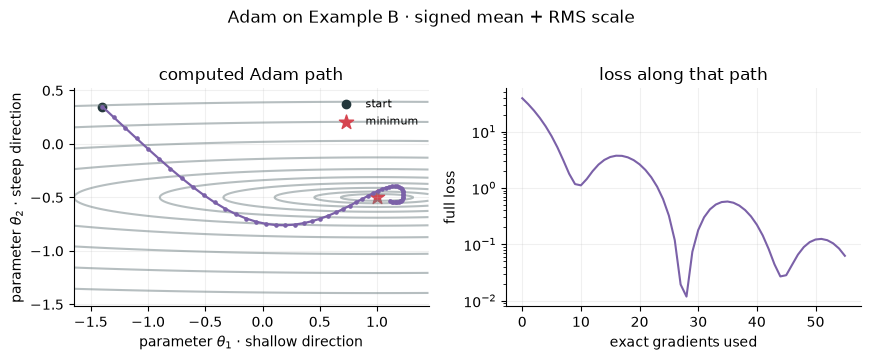

Adam loss: 39.005000 -> 0.062601 after 55 gradients
Adam raw flips=3 | material crossings=3


In [9]:
def adam_trace(eta=.10, beta1=.9, beta2=.999, steps=55, eps=1e-8):
    theta = theta0.copy()
    first_moment = np.zeros_like(theta0)
    second_moment = np.zeros_like(theta0)
    path = [theta.copy()]
    first_history = [first_moment.copy()]
    second_history = [second_moment.copy()]
    for step in range(1, steps + 1):
        gradient = ravine_grad(theta)
        theta, first_moment, second_moment, _, _, _ = adam_step(
            theta, gradient, first_moment, second_moment, step,
            eta, beta1, beta2, eps)
        path.append(theta.copy())
        first_history.append(first_moment.copy())
        second_history.append(second_moment.copy())
    return np.asarray(path), np.asarray(first_history), np.asarray(second_history)


def adam_path(eta=.10, beta1=.9, beta2=.999, steps=55, eps=1e-8):
    return adam_trace(eta, beta1, beta2, steps, eps)[0]


adam, adam_m, adam_v = adam_trace(steps=55)
adam_losses = np.array([ravine_loss(theta) for theta in adam])

print('ADAM STATE AFTER EACH OF THE FIRST THREE UPDATES')
print(' k |   theta_1   theta_2 |    m[k,1]    m[k,2] |     v[k,1]     v[k,2] | full loss')
for k in range(4):
    print(f'{k:2d} | {adam[k,0]:9.4f} {adam[k,1]:9.4f} | '
          f'{adam_m[k,0]:9.4f} {adam_m[k,1]:9.4f} | '
          f'{adam_v[k,0]:9.5f} {adam_v[k,1]:9.5f} | {adam_losses[k]:9.4f}')

fig, axes = plt.subplots(1, 2, figsize=(8.9, 3.45))
axes[0].contour(THETA1, THETA2, LGRID, levels=LEVELS, colors='#6E7F82', alpha=.5)
axes[0].plot(adam[:, 0], adam[:, 1], 'o-', ms=2.3, lw=1.6, color=PURPLE)
axes[0].scatter(*theta0, color=INK, label='start')
axes[0].scatter(*theta_star, marker='*', s=115, color=RED, label='minimum')
axes[0].set(xlabel='parameter $\\theta_1$ · shallow direction',
            ylabel='parameter $\\theta_2$ · steep direction',
            title='computed Adam path', xlim=(-1.65, 1.45), ylim=(-1.52, .52))
axes[0].legend(frameon=False, fontsize=8)
axes[1].semilogy(adam_losses, color=PURPLE)
axes[1].set(xlabel='exact gradients used', ylabel='full loss', title='loss along that path')
plt.suptitle('Adam on Example B · signed mean + RMS scale', y=1.03)
plt.tight_layout(); plt.show()

print(f'Adam loss: {adam_losses[0]:.6f} -> {adam_losses[-1]:.6f} after 55 gradients')
print(f'Adam raw flips={raw_crossings(adam)} | material crossings={material_crossings(adam)}')
assert np.allclose(adam[1], theta1_adam, atol=1e-8)
assert np.allclose(adam[2], theta2_adam, atol=1e-8)
assert np.isclose(adam_losses[-1], 0.06260063530642351)
assert material_crossings(adam) == 3


### Mapping Adam's two states to PyTorch

PyTorch stores the same two uncorrected memories:

- `state['exp_avg']` is $\boldsymbol m_t$, the signed first-moment estimate;
- `state['exp_avg_sq']` is $\boldsymbol v_t$, the second raw-moment estimate.

The bias-corrected quantities are computed transiently while forming the update; PyTorch does not replace the stored raw states by their corrected versions. The check below compares the complete parameter path and both stored histories with our vectorized function.


In [10]:
steps = 15
numpy_adam, numpy_exp_avg, numpy_exp_avg_sq = adam_trace(steps=steps)

theta_param = torch.nn.Parameter(torch.tensor(theta0, dtype=torch.float64))
opt = torch.optim.Adam(
    [theta_param], lr=.10, betas=(.9, .999), eps=1e-8, weight_decay=0)

torch_adam = [theta_param.detach().numpy().copy()]
torch_exp_avg = [np.zeros_like(theta0)]
torch_exp_avg_sq = [np.zeros_like(theta0)]
for _ in range(steps):
    opt.zero_grad(set_to_none=True)
    objective = .5 * ((Xt @ theta_param - yt)**2).mean()
    objective.backward()
    opt.step()
    state = opt.state[theta_param]
    torch_adam.append(theta_param.detach().numpy().copy())
    torch_exp_avg.append(state['exp_avg'].detach().numpy().copy())
    torch_exp_avg_sq.append(state['exp_avg_sq'].detach().numpy().copy())

torch_adam = np.asarray(torch_adam)
torch_exp_avg = np.asarray(torch_exp_avg)
torch_exp_avg_sq = np.asarray(torch_exp_avg_sq)

print('first PyTorch exp_avg:   ', torch_exp_avg[1])
print('first PyTorch exp_avg_sq:', torch_exp_avg_sq[1])
print(f'maximum parameter-path difference: {np.max(np.abs(torch_adam-numpy_adam)):.3e}')
print(f'maximum exp_avg difference:        {np.max(np.abs(torch_exp_avg-numpy_exp_avg)):.3e}')
print(f'maximum exp_avg_sq difference:     {np.max(np.abs(torch_exp_avg_sq-numpy_exp_avg_sq)):.3e}')

assert np.allclose(torch_adam, numpy_adam, atol=1e-12)
assert np.allclose(torch_exp_avg, numpy_exp_avg, atol=1e-12)
assert np.allclose(torch_exp_avg_sq, numpy_exp_avg_sq, atol=1e-12)


first PyTorch exp_avg:    [-0.24  8.5 ]
first PyTorch exp_avg_sq: [5.760e-03 7.225e+00]
maximum parameter-path difference: 1.110e-16
maximum exp_avg difference:        5.329e-15
maximum exp_avg_sq difference:     6.939e-18


## 3. One ravine, four mechanisms

Every run below starts at the same actual parameters $\boldsymbol\theta_0=(-1.4,.35)$ and receives 55 exact full-batch gradients of the same four-example empirical loss. We put all four loss curves on **one shared axis** so the evidence is readable before interpreting the optimizer names.

GD and normalized-EWMA momentum use the **same** learning rate $\eta=.0195$ below. RMSProp and Adam retain their own displayed rates because their rescaled updates have different units. This is a **controlled example, not a universal optimizer ranking**:

- GD uses the raw gradient;
- momentum filters its direction;
- RMSProp rescales each coordinate;
- Adam combines signed direction memory with per-coordinate rulers, correcting both zero-start memories.

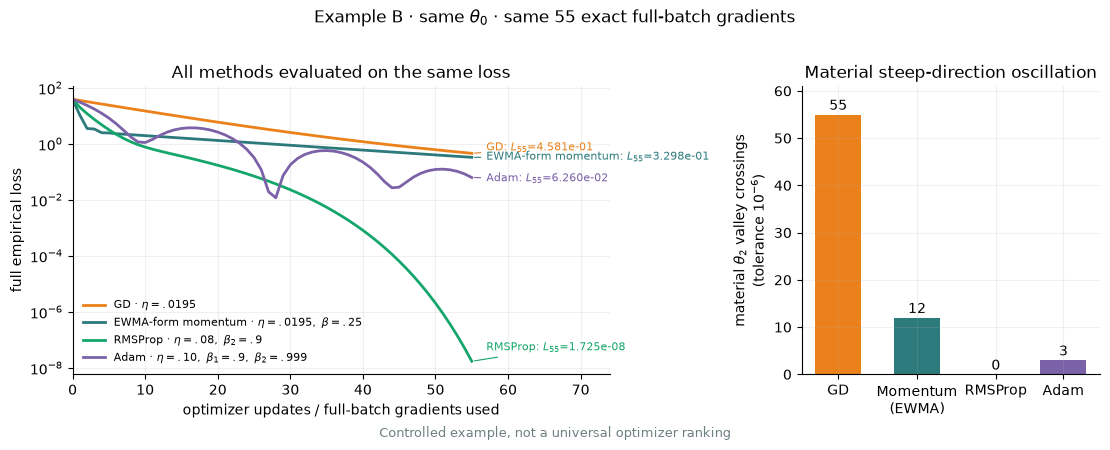

Controlled Example B | same theta0 | 55 exact full-batch gradients
rank  method                    L_55          theta2 valley crossings
   1  RMSProp                 1.724812e-08                        0
   2  Adam                    6.260064e-02                        3
   3  EWMA-form momentum      3.297749e-01                       12
   4  GD                      4.581442e-01                       55
Here: adaptive scaling finishes lower. RMSProp has the lowest L_55 and
zero material theta2 crossings; Adam has 3. This is not a universal ranking.


In [11]:
def momentum_path(eta=.0195, beta=.25, steps=55):
    theta, m, path = theta0.copy(), np.zeros(2), [theta0.copy()]
    for _ in range(steps):
        m = beta * m + (1 - beta) * ravine_grad(theta)
        theta -= eta * m; path.append(theta.copy())
    return np.asarray(path)

def material_crossings(path, tolerance=1e-6):
    steep_error = np.asarray(path)[:, 1] - theta_star[1]
    changed_sign_bit = np.signbit(steep_error[:-1]) != np.signbit(steep_error[1:])
    adjacent_scale = np.maximum(np.abs(steep_error[:-1]), np.abs(steep_error[1:]))
    return int(np.sum(changed_sign_bit & (adjacent_scale > tolerance)))

methods = [
    ('GD', gd_path(.0195, 55), ORANGE, r'$\eta=.0195$'),
    ('EWMA-form momentum', momentum_path(.0195, .25, 55), TEAL, r'$\eta=.0195,\ \beta=.25$'),
    ('RMSProp', rmsprop_path(.08, .9, 55), GREEN, r'$\eta=.08,\ \beta_2=.9$'),
    ('Adam', adam_path(.10, .9, .999, 55), PURPLE, r'$\eta=.10,\ \beta_1=.9,\ \beta_2=.999$'),
]
metrics = []
for name, path_now, color, rate_label in methods:
    losses = np.array([ravine_loss(theta) for theta in path_now])
    metrics.append({'name': name, 'path': path_now, 'color': color, 'rate': rate_label,
                    'losses': losses, 'L55': losses[-1],
                    'crossings': material_crossings(path_now)})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.15),
                         gridspec_kw={'width_ratios': [1.8, 1]})
for item in metrics:
    axes[0].semilogy(range(56), item['losses'], lw=2.0, color=item['color'],
                    label=f"{item['name']} · {item['rate']}")
axes[0].set(xlabel='optimizer updates / full-batch gradients used',
            ylabel='full empirical loss', xlim=(0, 74),
            title='All methods evaluated on the same loss')
axes[0].legend(frameon=False, fontsize=8, loc='lower left')

# Endpoint labels make the controlled L_55 result explicit.
endpoint_y = {'GD': .55, 'EWMA-form momentum': .26, 'Adam': .044, 'RMSProp': 4.0e-8}
for item in metrics:
    axes[0].annotate(f"{item['name']}: $L_{{55}}$={item['L55']:.3e}",
                     xy=(55, item['L55']), xytext=(57, endpoint_y[item['name']]),
                     color=item['color'], fontsize=8,
                     arrowprops={'arrowstyle': '-', 'color': item['color'], 'lw': .8})

names = ['GD', 'Momentum\n(EWMA)', 'RMSProp', 'Adam']
crossings = [item['crossings'] for item in metrics]
colors = [item['color'] for item in metrics]
bar_x = np.array([0., 1.4, 2.8, 4.0])
bars = axes[1].bar(bar_x, crossings, width=.82, color=colors)
axes[1].set_xticks(bar_x, names); axes[1].set_xlim(-.65, 4.65)
axes[1].set(ylabel='material $\\theta_2$ valley crossings\n(tolerance $10^{-6}$)',
            title='Material steep-direction oscillation', ylim=(0, 61))
for bar, count in zip(bars, crossings):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

fig.suptitle('Example B · same $\\theta_0$ · same 55 exact full-batch gradients', y=1.02)
fig.text(.5, -.01, 'Controlled example, not a universal optimizer ranking',
         ha='center', color='#6E7F82', fontsize=9)
plt.tight_layout(); plt.show()

ranking = sorted(metrics, key=lambda item: item['L55'])
print('Controlled Example B | same theta0 | 55 exact full-batch gradients')
print('rank  method                    L_55          theta2 valley crossings')
for rank, item in enumerate(ranking, start=1):
    print(f"{rank:>4}  {item['name']:<23} {item['L55']:.6e}  {item['crossings']:>23}")
print('Here: adaptive scaling finishes lower. RMSProp has the lowest L_55 and')
print('zero material theta2 crossings; Adam has 3. This is not a universal ranking.')

metric_by_name = {item['name']: item for item in metrics}
assert [item['name'] for item in ranking] == ['RMSProp', 'Adam', 'EWMA-form momentum', 'GD']
assert np.isclose(metric_by_name['GD']['L55'], 0.458144212675313)
assert np.isclose(metric_by_name['EWMA-form momentum']['L55'], 0.32977487865641175)
assert np.all(np.diff(metric_by_name['GD']['losses']) < 0)
assert np.all(np.diff(metric_by_name['EWMA-form momentum']['losses']) < 0)
assert metric_by_name['GD']['crossings'] == 55
assert metric_by_name['EWMA-form momentum']['crossings'] == 12
assert metric_by_name['RMSProp']['crossings'] == 0
assert metric_by_name['Adam']['crossings'] == 3
assert metric_by_name['RMSProp']['L55'] < metric_by_name['Adam']['L55']
assert metric_by_name['Adam']['L55'] < metric_by_name['EWMA-form momentum']['L55']

## 4. Learning-rate schedules: change the step scale over training

Every optimizer first proposes a direction $\boldsymbol d_t$ and then takes a step:

$$\boxed{\boldsymbol\theta_{t+1}=\boldsymbol\theta_t-\eta_t\boldsymbol d_t.}$$

For plain GD, $\boldsymbol d_t=\widehat{\boldsymbol g}_t$. Momentum uses its signed-gradient memory, RMSProp uses a gradient divided by its recent componentwise scale, and Adam combines both memories. A schedule changes only the scalar $\eta_t$; it does **not** change how the optimizer constructs $\boldsymbol d_t$. Because the parameters move to a different point, later gradients can of course differ.

In [12]:
def apply_scheduled_step(theta, direction, eta_t):
    return theta - eta_t * direction

# Illustrative directions already constructed by four optimizers at one update.
directions = {
    'plain GD': np.array([2.0, -4.0]),
    'momentum': np.array([1.5, -2.5]),
    'RMSProp': np.array([0.6, -0.8]),
    'Adam': np.array([0.5, -0.7]),
}
theta_demo = np.array([1.0, -0.5])
eta_early, eta_late = .10, .02
print('same wrapper: theta_next = theta - eta_t * direction')
for name, direction in directions.items():
    early_move = apply_scheduled_step(theta_demo, direction, eta_early) - theta_demo
    late_move = apply_scheduled_step(theta_demo, direction, eta_late) - theta_demo
    ratio = np.linalg.norm(late_move) / np.linalg.norm(early_move)
    print(f'{name:10s} | late/early move length = {ratio:.1f}')
    assert np.allclose(late_move, (eta_late / eta_early) * early_move)


same wrapper: theta_next = theta - eta_t * direction
plain GD   | late/early move length = 0.2
momentum   | late/early move length = 0.2
RMSProp    | late/early move length = 0.2
Adam       | late/early move length = 0.2


### Exact and sampled gradients behave differently near an optimum

Return to Example A, with $\widehat y_i=b+wx_i$ and $\ell_i=\tfrac12(\widehat y_i-y_i)^2$. Its least-squares solution is $\boldsymbol\theta^*=(b^*,w^*)=(1.1,2.3)$. At that point,

$$\nabla\mathcal L(\boldsymbol\theta^*)=\frac14\sum_{i=1}^4\nabla\ell_i(\boldsymbol\theta^*)=\boldsymbol 0,$$

but the four individual gradients are not zero. Full-batch GD therefore stops, while SGD can still move when it samples one example. Under uniform sampling, the sampled gradient has zero mean at $\boldsymbol\theta^*$, not zero variance. Consequently,

$$\operatorname{Cov}(\Delta\boldsymbol\theta_t\mid\boldsymbol\theta^*)=\eta_t^2\operatorname{Cov}(\widehat{\boldsymbol g}_t\mid\boldsymbol\theta^*).$$

This is the cleanest reason decay is especially useful with stochastic or minibatch updates: reducing $\eta_t$ directly shrinks late random motion. Schedules can also help exact GD with stability or refinement, but exact GD has no sampling-driven wandering at its optimum.

theta* = [1.1 2.3]
i   x_i   y_i     individual gradient at theta*
1    -1    -1     (-0.200,  0.200)
2     0     1     ( 0.100,  0.000)
3     1     3     ( 0.400,  0.400)
4     2     6     (-0.300, -0.600)
uniform mean = [0. 0.]


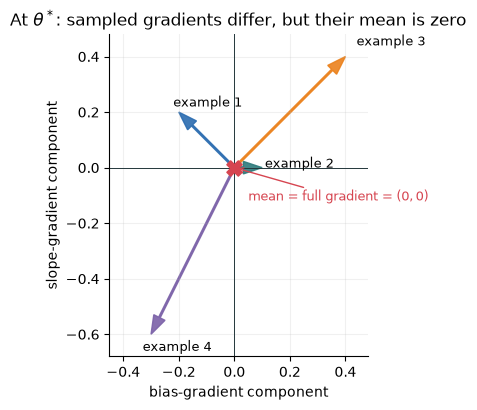

In [13]:
x_line = np.array([-1., 0., 1., 2.])
y_line = np.array([-1., 1., 3., 6.])
A_line = np.column_stack([np.ones_like(x_line), x_line])
theta_line0 = np.array([2., -1.])
theta_line_star = np.linalg.lstsq(A_line, y_line, rcond=None)[0]

def line_loss(theta):
    return .5 * np.mean((A_line @ theta - y_line)**2)

def sample_grad(theta, i):
    residual = A_line[i] @ theta - y_line[i]
    return residual * A_line[i]

sample_grads_star = np.stack([sample_grad(theta_line_star, i) for i in range(4)])
full_grad_star = sample_grads_star.mean(axis=0)
print('theta* =', np.round(theta_line_star, 3))
print('i   x_i   y_i     individual gradient at theta*')
for i, (x_i, y_i, grad_i) in enumerate(zip(x_line, y_line, sample_grads_star), start=1):
    print(f'{i}  {x_i:4.0f}  {y_i:4.0f}     ({grad_i[0]: .3f}, {grad_i[1]: .3f})')
print('uniform mean =', np.round(full_grad_star, 12))

fig, ax = plt.subplots(figsize=(5.6, 4.2))
for i, grad_i in enumerate(sample_grads_star, start=1):
    ax.arrow(0, 0, grad_i[0], grad_i[1], width=.006, head_width=.045,
             length_includes_head=True, color=[BLUE, TEAL, ORANGE, PURPLE][i-1], alpha=.9)
    ax.text(*(1.10 * grad_i), f'example {i}', fontsize=9)
ax.scatter(0, 0, marker='X', s=120, color=RED, zorder=5)
ax.annotate('mean = full gradient = $(0,0)$', xy=(0, 0), xytext=(.05, -.12),
            arrowprops={'arrowstyle': '->', 'color': RED}, color=RED, fontsize=9)
ax.axhline(0, color=INK, lw=.7); ax.axvline(0, color=INK, lw=.7)
ax.set(xlabel='bias-gradient component', ylabel='slope-gradient component',
       title=r'At $\theta^*$: sampled gradients differ, but their mean is zero',
       xlim=(-.45,.48), ylim=(-.68,.48))
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

assert np.allclose(theta_line_star, [1.1, 2.3])
assert np.allclose(sample_grads_star, [[-.2,.2],[.1,0],[.4,.4],[-.3,-.6]])
assert np.allclose(full_grad_star, 0, atol=1e-12)
assert np.all(np.linalg.norm(sample_grads_star, axis=1) > 0)


### Seeded experiment: travel early, refine late

Return to Example A and compare three SGD runs from the same $\theta_0$. Every run receives the same 360 sample indices, drawn with replacement using seed 12:

$$\text{large fixed: }\eta_t=.10,\qquad \text{small fixed: }\eta_t=.02,\qquad \text{inverse-time: }\eta_t=\frac{.10}{1+.02t}.$$

We measure three concrete quantities: the first update at which the full-loss gap falls below $.5$, the distance travelled over the final 99 parameter transitions, and the mean full-loss gap over the final 100 updates. The optimizer and sample stream are fixed; only the learning-rate policy changes.

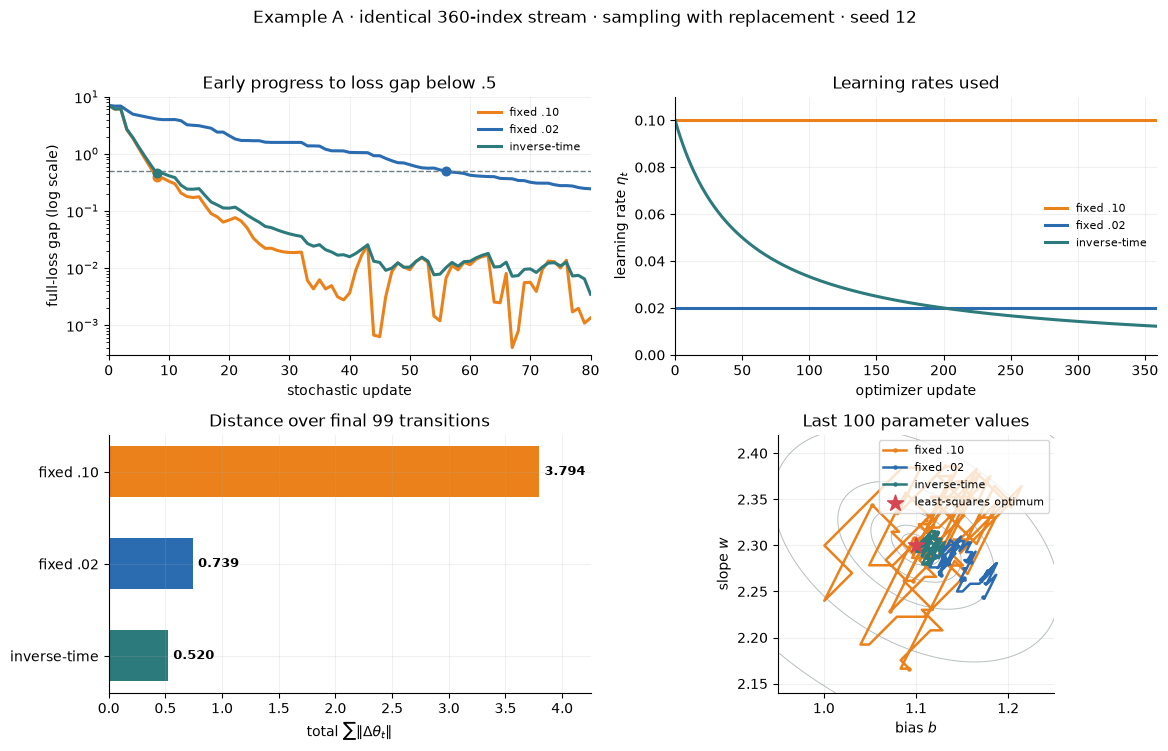

inverse-time checkpoints: eta_0=0.1000, eta_50=0.0500, eta_350=0.0125
policy          first gap < .5   late distance   late mean gap
fixed .10                    8     3.794479822  0.004099611449
fixed .02                   56     0.739120733  0.001287101616
inverse-time                 8     0.520387237  0.000201402373


In [14]:
def run_stream(indices, schedule):
    theta, path, losses = theta_line0.copy(), [theta_line0.copy()], []
    for t, i in enumerate(indices):
        theta -= schedule(t) * sample_grad(theta, i)
        path.append(theta.copy()); losses.append(line_loss(theta))
    return np.asarray(path), np.asarray(losses)

rng = np.random.default_rng(SEED)
indices = rng.integers(0, 4, 360)  # sampling with replacement
ETA_LARGE, ETA_SMALL, DECAY = .10, .02, .02
updates = np.arange(len(indices))
policies = {
    'fixed .10': lambda _t: ETA_LARGE,
    'fixed .02': lambda _t: ETA_SMALL,
    'inverse-time': lambda t: ETA_LARGE / (1 + DECAY * t),
}
paths, losses = {}, {}
for name, schedule in policies.items():
    paths[name], losses[name] = run_stream(indices, schedule)
rates = {
    'fixed .10': np.full(len(indices), ETA_LARGE),
    'fixed .02': np.full(len(indices), ETA_SMALL),
    'inverse-time': ETA_LARGE / (1 + DECAY * updates),
}
colors = {'fixed .10': ORANGE, 'fixed .02': BLUE, 'inverse-time': TEAL}
optimum_loss = line_loss(theta_line_star)
gaps = {name: values - optimum_loss for name, values in losses.items()}

def first_below(values, threshold):
    hits = np.flatnonzero(values < threshold)
    assert len(hits) > 0
    return int(hits[0] + 1)  # losses[0] is measured after update 1

travel_updates = {name: first_below(values, .5) for name, values in gaps.items()}
late_mean_gap = {name: float(values[-100:].mean()) for name, values in gaps.items()}
# The final 100 path points contain 99 actual parameter transitions.
late_distance = {
    name: float(np.linalg.norm(np.diff(path[-100:], axis=0), axis=1).sum())
    for name, path in paths.items()
}

fig, axes = plt.subplots(2, 2, figsize=(11.8, 7.5))
early_horizon = 80
early_updates = np.arange(early_horizon + 1)
start_gap = line_loss(theta_line0) - optimum_loss
for name in policies:
    early_gap = np.r_[start_gap, gaps[name][:early_horizon]]
    axes[0, 0].semilogy(early_updates, early_gap, color=colors[name], lw=2.2, label=name)
    hit = travel_updates[name]
    axes[0, 0].scatter(hit, gaps[name][hit - 1], color=colors[name], s=38, zorder=5)
axes[0, 0].axhline(.5, color='#6E7F82', lw=1, ls='--')
axes[0, 0].set(xlim=(0, early_horizon), ylim=(3e-4, 10), xlabel='stochastic update',
               ylabel='full-loss gap (log scale)', title='Early progress to loss gap below .5')
axes[0, 0].legend(frameon=False, fontsize=8)

for name in policies:
    axes[0, 1].plot(updates, rates[name], color=colors[name], lw=2.2, label=name)
axes[0, 1].set(xlim=(0, 359), ylim=(0, .11), xlabel='optimizer update',
               ylabel=r'learning rate $\eta_t$', title='Learning rates used')
axes[0, 1].legend(frameon=False, fontsize=8)

names = list(policies)
bars = axes[1, 0].barh(names, [late_distance[name] for name in names],
                         color=[colors[name] for name in names], height=.55)
axes[1, 0].invert_yaxis()
axes[1, 0].bar_label(bars, labels=[f'{late_distance[name]:.3f}' for name in names],
                     padding=4, fontsize=9, weight='bold')
axes[1, 0].set(xlim=(0, 4.25), xlabel=r'total $\sum\|\Delta\theta_t\|$',
               title='Distance over final 99 transitions')

b = np.linspace(.95, 1.25, 220); w = np.linspace(2.14, 2.42, 220)
B, W = np.meshgrid(b, w)
LG = .5 * np.mean((B[..., None] + W[..., None] * x_line - y_line)**2, axis=-1)
axes[1, 1].contour(B, W, LG, levels=optimum_loss + np.array([.0001,.0003,.001,.003,.01,.03]),
                   colors='#6E7F82', linewidths=.7, alpha=.5)
for name in policies:
    late = paths[name][-100:]
    axes[1, 1].plot(late[:, 0], late[:, 1], color=colors[name], lw=1.8, marker='o',
                    ms=2.2, markevery=9, label=name)
axes[1, 1].scatter(*theta_line_star, marker='*', s=145, color=RED, zorder=6,
                   label='least-squares optimum')
axes[1, 1].set(xlim=(.95, 1.25), ylim=(2.14, 2.42), xlabel='bias $b$', ylabel='slope $w$',
               title='Last 100 parameter values')
axes[1, 1].set_aspect('equal'); axes[1, 1].legend(frameon=True, fontsize=8, loc='upper right')
fig.suptitle('Example A · identical 360-index stream · sampling with replacement · seed 12', y=.995)
plt.tight_layout(rect=(0, 0, 1, .97)); plt.show()

print('inverse-time checkpoints: ' + ', '.join(
    f'eta_{t}={rates["inverse-time"][t]:.4f}' for t in [0, 50, 350]))
print(f"{'policy':14s} {'first gap < .5':>15s} {'late distance':>15s} {'late mean gap':>15s}")
for name in names:
    print(f'{name:14s} {travel_updates[name]:15d} {late_distance[name]:15.9f} {late_mean_gap[name]:15.12f}')

assert travel_updates == {'fixed .10': 8, 'fixed .02': 56, 'inverse-time': 8}
expected_late_distance = {
    'fixed .10': 3.794479821649366,
    'fixed .02': .7391207330467251,
    'inverse-time': .520387236914856,
}
expected_late_mean_gap = {
    'fixed .10': .004099611448621285,
    'fixed .02': .0012871016156542003,
    'inverse-time': .00020140237311844306,
}
for name in names:
    assert np.isclose(late_distance[name], expected_late_distance[name])
    assert np.isclose(late_mean_gap[name], expected_late_mean_gap[name])
    assert np.allclose(paths[name][0], theta_line0)
assert np.isclose(rates['inverse-time'][0], .10)
assert np.isclose(rates['inverse-time'][50], .05)
assert np.isclose(rates['inverse-time'][350], .0125)
assert np.isclose(rates['inverse-time'][-1], .012224938875305624)
assert late_distance['inverse-time'] < late_distance['fixed .02'] < late_distance['fixed .10']
assert late_mean_gap['inverse-time'] < late_mean_gap['fixed .02'] < late_mean_gap['fixed .10']

### Six schedule shapes

Let $u=\min(t/T,1)$ be progress through a chosen horizon of $T=100$ optimizer updates. To compare **shape** rather than arbitrary scales, every schedule uses the same peak $.10$ and floor $.01$:

- **inverse-time:** $\eta_t=\eta_{\max}/(1+9u)$;
- **exponential:** multiply by the same factor per unit progress;
- **linear:** subtract the same amount per unit progress;
- **milestone/step:** make discrete drops at chosen updates;
- **cosine:** begin and end gently;
- **warmup + cosine:** rise from $.01$ to $.10$ during the first 10 updates, then decay smoothly to $.01$.

These are shapes, not a ranking. Their best horizon, endpoints, and clock depend on the task. Here, $t$ always counts actual calls to `optimizer.step()`.

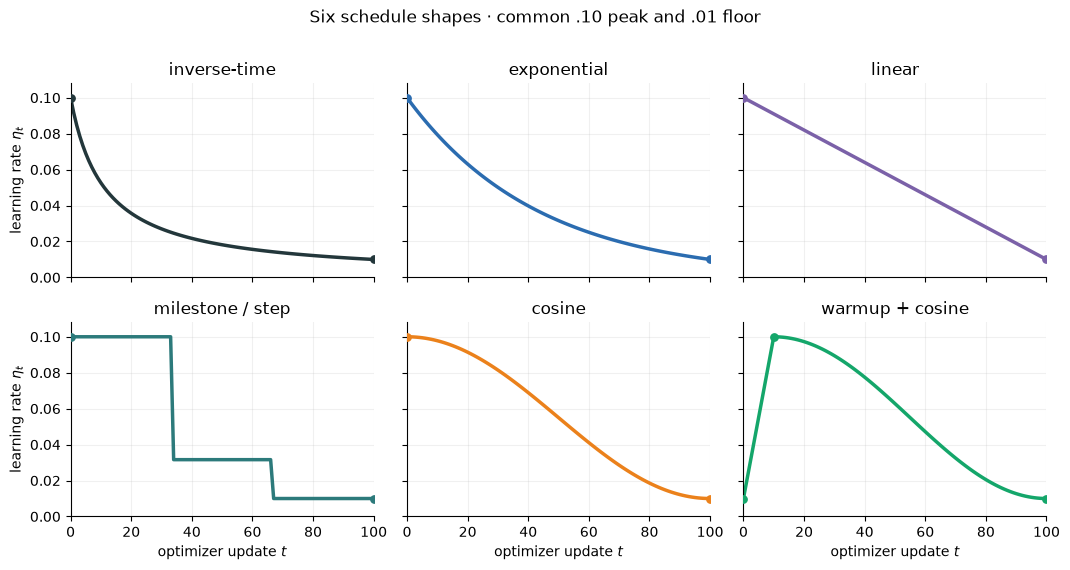

schedule          eta_0  eta_10  eta_25  eta_50  eta_75 eta_100
inverse-time        0.1000   0.0526   0.0308   0.0182   0.0129   0.0100
exponential         0.1000   0.0794   0.0562   0.0316   0.0178   0.0100
linear              0.1000   0.0910   0.0775   0.0550   0.0325   0.0100
milestone / step    0.1000   0.1000   0.1000   0.0316   0.0100   0.0100
cosine              0.1000   0.0978   0.0868   0.0550   0.0232   0.0100
warmup + cosine     0.0100   0.1000   0.0940   0.0628   0.0261   0.0100


In [15]:
T = 100
schedule_updates = np.arange(T + 1)
u = np.clip(schedule_updates / T, 0, 1)
eta_max, eta_min = .10, .01

warmup_updates = 10
post_warmup_u = np.clip((schedule_updates - warmup_updates) / (T - warmup_updates), 0, 1)
warmup_cosine = np.where(
    schedule_updates <= warmup_updates,
    eta_min + (eta_max - eta_min) * schedule_updates / warmup_updates,
    eta_min + .5 * (eta_max - eta_min) * (1 + np.cos(np.pi * post_warmup_u)),
)

schedule_values = {
    'inverse-time': eta_max / (1 + (eta_max / eta_min - 1) * u),
    'exponential': eta_max * (eta_min / eta_max)**u,
    'linear': eta_min + (eta_max - eta_min) * (1 - u),
    'milestone / step': np.where(
        u < 1 / 3, eta_max, np.where(u < 2 / 3, np.sqrt(eta_max * eta_min), eta_min)
    ),
    'cosine': eta_min + .5 * (eta_max - eta_min) * (1 + np.cos(np.pi * u)),
    'warmup + cosine': warmup_cosine,
}
schedule_colors = [INK, BLUE, PURPLE, TEAL, ORANGE, GREEN]
fig, axes = plt.subplots(2, 3, figsize=(10.8, 5.6), sharex=True, sharey=True)
for ax, (name, rates), color in zip(axes.flat, schedule_values.items(), schedule_colors):
    ax.plot(schedule_updates, rates, color=color, lw=2.5)
    highlight = [0, T] if name != 'warmup + cosine' else [0, warmup_updates, T]
    ax.scatter(highlight, rates[highlight], color=color, s=28, zorder=4)
    ax.set(title=name, xlim=(0, T), ylim=(0, .108))
for ax in axes[-1]: ax.set_xlabel('optimizer update $t$')
for ax in axes[:, 0]: ax.set_ylabel(r'learning rate $\eta_t$')
fig.suptitle('Six schedule shapes · common .10 peak and .01 floor', y=1.01)
plt.tight_layout(); plt.show()

marks = np.array([0, 10, 25, 50, 75, 100])
print('schedule          eta_0  eta_10  eta_25  eta_50  eta_75 eta_100')
for name, rates in schedule_values.items():
    print(f"{name:17s} " + ' '.join(f'{rates[t]:8.4f}' for t in marks))
assert list(schedule_values) == [
    'inverse-time', 'exponential', 'linear',
    'milestone / step', 'cosine', 'warmup + cosine'
]
for name, rates in schedule_values.items():
    assert np.all(rates > 0)
    assert np.isclose(rates.max(), eta_max)
    assert np.isclose(rates[-1], eta_min)
    if name != 'warmup + cosine':
        assert np.isclose(rates[0], eta_max)
        assert np.all(np.diff(rates) <= 1e-12)
assert np.isclose(warmup_cosine[0], eta_min)
assert np.isclose(warmup_cosine[warmup_updates], eta_max)
assert np.all(np.diff(warmup_cosine[:warmup_updates + 1]) >= -1e-12)
assert np.all(np.diff(warmup_cosine[warmup_updates:]) <= 1e-12)


### PyTorch: inverse-time and cosine schedules use the same update clock

A PyTorch scheduler wraps an optimizer object, so the same scheduler pattern can wrap `SGD`, `RMSprop`, or `Adam`. The seeded experiment uses $\eta_t=\eta_0/(1+dt)$; `LambdaLR` implements that formula exactly. `CosineAnnealingLR` supplies the cosine shape.

Record the rate, execute `optimizer.step()`, and only then call `scheduler.step()`. Thus optimizer update $t$ uses $\eta_t$, and the scheduler prepares $\eta_{t+1}$. This clock counts executed optimizer updates, not whether floating-point parameter values happened to change: a zero-gradient step still counts. If an update is skipped—for example, `GradScaler` detects an AMP overflow and does not execute the optimizer step—do not advance an update-based scheduler. Forward passes and accumulated minibatches do not advance this clock on their own.

In [16]:
eta0, decay, num_updates = .10, .02, 8
dummy = torch.nn.Parameter(torch.tensor(1.0))
optimizer = torch.optim.SGD([dummy], lr=eta0)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer, lr_lambda=lambda t: 1.0 / (1.0 + decay * t))

rates_used = []
for update in range(num_updates):
    rates_used.append(optimizer.param_groups[0]['lr'])
    optimizer.zero_grad(set_to_none=True)
    (0.5 * dummy.square()).backward()
    optimizer.step()       # executed optimizer update t uses eta_t
    scheduler.step()       # prepare eta_(t+1)

expected_rates = np.array([eta0 / (1 + decay * t) for t in range(num_updates)])
print('rates used per optimizer update:', np.round(rates_used, 6))
assert np.allclose(rates_used, expected_rates)

rates used per optimizer update: [0.1      0.098039 0.096154 0.09434  0.092593 0.090909 0.089286 0.087719]


In [17]:
eta_max, eta_min, num_updates = .10, .01, 8
dummy_cos = torch.nn.Parameter(torch.tensor(1.0))
optimizer_cos = torch.optim.SGD([dummy_cos], lr=eta_max)  # Adam(...) works too
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cos, T_max=num_updates, eta_min=eta_min)

cosine_rates_used = []
for update in range(num_updates):
    cosine_rates_used.append(optimizer_cos.param_groups[0]['lr'])
    optimizer_cos.zero_grad(set_to_none=True)
    (0.5 * dummy_cos.square()).backward()
    optimizer_cos.step()       # update t uses the recorded eta_t
    scheduler_cos.step()       # prepare eta_(t+1)

cosine_expected = eta_min + .5 * (eta_max - eta_min) * (
    1 + np.cos(np.pi * np.arange(num_updates) / num_updates))
print('cosine rates used per optimizer update:', np.round(cosine_rates_used, 6))
print('rate prepared after the final scheduler.step():',
      round(optimizer_cos.param_groups[0]['lr'], 6))
assert np.allclose(cosine_rates_used, cosine_expected)
assert np.isclose(optimizer_cos.param_groups[0]['lr'], eta_min)


cosine rates used per optimizer update: [0.1      0.096575 0.08682  0.072221 0.055    0.037779 0.02318  0.013425]
rate prepared after the final scheduler.step(): 0.01


## 5. Constraints come from the model, not the optimizer

A standard optimizer proposes values in $\mathbb R^d$. The **model** decides which values are meaningful. Four recurring families are:

| family | model quantity | requirement | useful unconstrained variable |
|---|---|---|---|
| positive | Gaussian noise scale $\sigma$ | $\sigma>0$ | $a\in\mathbb R$, $\sigma=\exp(a)$ |
| box | blend coefficient $c$ | $a\le c\le b$ | $r\in\mathbb R$, $c=a+(b-a)\operatorname{sigmoid}(r)$ |
| probability | Bernoulli probability $p$ | $0\le p\le1$ | logit $z\in\mathbb R$, $p=\operatorname{sigmoid}(z)$ |
| simplex | class or mixture weights $\boldsymbol\pi$ | $\pi_k\ge0$, $\sum_k\pi_k=1$ | logits $\boldsymbol z\in\mathbb R^K$, $\boldsymbol\pi=\operatorname{softmax}(\boldsymbol z)$ |

The reusable pattern is: **store an unconstrained raw parameter, transform it inside the forward pass, and let autograd apply the chain rule.** Finite sigmoid and softmax logits cover the strict interior of the valid probability sets; the boundary values remain valid model parameters but require limiting logits or a different constraint mechanism.

Why is a repair needed? Consider a Gaussian scale $\sigma>0$ and one residual
$r=y-\mu=.05$. Up to the additive constant $\tfrac12\log(2\pi)$, its Gaussian negative log-likelihood contribution is

$$
\mathcal L(\sigma)=\log\sigma+\frac{.05^2}{2\sigma^2},
\qquad \frac{\partial\mathcal L}{\partial\sigma}=\frac1\sigma-\frac{.05^2}{\sigma^3}.
$$

At $\sigma_0=.10$, the gradient is $7.5$. A plain step with $\eta=.02$ proposes $\sigma_1=.10-.02(7.5)=-.05$. The derivative is correct, but the proposal is not a valid scale.


In [18]:
residual_constraint = .05
sigma0, eta_constraint = .10, .02
grad_sigma0 = 1 / sigma0 - residual_constraint**2 / sigma0**3
sigma_proposal = sigma0 - eta_constraint * grad_sigma0

print(f'sigma_0={sigma0:.2f},  dL/dsigma={grad_sigma0:.1f},  eta={eta_constraint:.2f}')
print(f'plain proposal: sigma_1={sigma0:.2f} - {eta_constraint:.2f}({grad_sigma0:.1f}) = {sigma_proposal:.2f}')
print('valid Gaussian scale?', sigma_proposal > 0)
assert np.isclose(grad_sigma0, 7.5)
assert np.isclose(sigma_proposal, -.05) and sigma_proposal <= 0


sigma_0=0.10,  dL/dsigma=7.5,  eta=0.02
plain proposal: sigma_1=0.10 - 0.02(7.5) = -0.05
valid Gaussian scale? False


## 6. Positive Gaussian noise: learn $\log\sigma$

In a homoskedastic Gaussian model, every observation shares one learned noise scale $\sigma$. Up to the additive constant $\tfrac12\log(2\pi)$,

$$
\mathcal L(\mu,\sigma)
=\frac1N\sum_{i=1}^N
\left[\log\sigma+\frac{(y_i-\mu)^2}{2\sigma^2}\right],
\qquad \sigma>0.
$$

Store an unconstrained $a\in\mathbb R$ and set

$$
\sigma=\exp(a)>0.
$$

The optimizer updates $a$; the forward pass reconstructs $\sigma$ every time. For heteroskedastic regression, a network produces one $a_i=a(x_i)$ per input and uses $\sigma_i=\exp(a_i)$ in exactly the same way.

`softplus(a)` is a common alternative when a gentler positive transform is useful. Both maps enforce strict positivity; `exp(a)` has the especially clear interpretation $a=\log\sigma$.


In [19]:
# Tiny homoskedastic Gaussian example: one mu and one sigma for all observations.
gaussian_y = torch.tensor([-1.0, -0.2, 0.3, 1.2], dtype=torch.float64)
mu = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
raw_a = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))  # a = log(sigma)
gaussian_opt = torch.optim.Adam([mu, raw_a], lr=.05)

for _ in range(300):
    gaussian_opt.zero_grad(set_to_none=True)
    sigma = raw_a.exp()  # rebuild the feasible value inside the forward pass
    gaussian_nll = (raw_a + .5 * ((gaussian_y - mu) / sigma).square()).mean()
    gaussian_nll.backward()
    gaussian_opt.step()

sigma = raw_a.exp()
analytic_mu = gaussian_y.mean()
analytic_sigma = ((gaussian_y - analytic_mu).square().mean()).sqrt()
print(f'learned mu={mu.item():.4f}, sigma=exp(a)={sigma.item():.4f}')
print(f'closed-form check: mu={analytic_mu.item():.4f}, sigma={analytic_sigma.item():.4f}')
print(f'raw a={raw_a.item():.4f}; sigma is positive by construction')

assert sigma.item() > 0
assert torch.allclose(mu, analytic_mu, atol=2e-4)
assert torch.allclose(sigma, analytic_sigma, atol=2e-4)


learned mu=0.0750, sigma=exp(a)=0.7980
closed-form check: mu=0.0750, sigma=0.7980
raw a=-0.2256; sigma is positive by construction


## 7. A bounded coefficient: map the real line into a box

Suppose two fixed predictors are blended as

$$
\widehat y=(1-c)f_0(x)+cf_1(x),\qquad 0\le c\le1.
$$

Within the box, $c=0$ selects $f_0$, $c=1$ selects $f_1$, and intermediate values interpolate. Outside the box the expression extrapolates and loses that interpretation.

For a general interval $[a,b]$, store $r\in\mathbb R$ and use

$$
c=a+(b-a)\operatorname{sigmoid}(r).
$$

The transform guarantees $a<c<b$ for every finite $r$. The tiny experiment below recovers a known blend from data while every intermediate $c$ remains feasible.


In [20]:
f0 = torch.tensor([0., 1., 2.], dtype=torch.float64)
f1 = torch.tensor([2., 2., 4.], dtype=torch.float64)
true_c = torch.tensor(.70, dtype=torch.float64)
blend_target = (1 - true_c) * f0 + true_c * f1

lower, upper = 0.0, 1.0
raw_c = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
blend_opt = torch.optim.Adam([raw_c], lr=.15)
c_history = []
for _ in range(160):
    blend_opt.zero_grad(set_to_none=True)
    c = lower + (upper - lower) * raw_c.sigmoid()
    prediction = (1 - c) * f0 + c * f1
    blend_loss = .5 * (prediction - blend_target).square().mean()
    blend_loss.backward()
    blend_opt.step()
    c_history.append(c.item())

c = lower + (upper - lower) * raw_c.sigmoid()
print(f'learned c={c.item():.4f}; target c={true_c.item():.2f}')
print(f'all {len(c_history)} forward-pass values stayed in (0, 1):',
      all(lower < value < upper for value in c_history))
assert all(lower < value < upper for value in c_history)
assert torch.allclose(c, true_c, atol=2e-4)


learned c=0.7000; target c=0.70
all 160 forward-pass values stayed in (0, 1): True


## 8. Bernoulli probabilities: optimize a logit

A Bernoulli model needs $p=P(y=1\mid x)\in(0,1)$. Store a real-valued **logit** $z$ and report

$$p=\operatorname{sigmoid}(z).$$

During training, prefer `BCEWithLogitsLoss` (or `binary_cross_entropy_with_logits`) and pass $z$ directly. It combines the sigmoid and logarithms in a numerically stable expression. Apply `sigmoid` only when a probability is needed for interpretation or prediction.

In the four-outcome example below, the maximum-likelihood probability is the observed fraction $3/4$.


In [21]:
bernoulli_y = torch.tensor([1., 0., 1., 1.], dtype=torch.float64)
probability_logit = torch.nn.Parameter(torch.tensor(0.0, dtype=torch.float64))
bernoulli_opt = torch.optim.Adam([probability_logit], lr=.15)
bernoulli_nll = torch.nn.BCEWithLogitsLoss()

for _ in range(200):
    bernoulli_opt.zero_grad(set_to_none=True)
    logits = probability_logit.expand_as(bernoulli_y)
    bernoulli_loss = bernoulli_nll(logits, bernoulli_y)
    bernoulli_loss.backward()
    bernoulli_opt.step()

probability = probability_logit.sigmoid()
print(f'learned logit={probability_logit.item():.4f}')
print(f'reported probability=sigmoid(logit)={probability.item():.4f}')
assert 0 < probability.item() < 1
assert torch.allclose(probability, bernoulli_y.mean(), atol=2e-4)


learned logit=1.0986
reported probability=sigmoid(logit)=0.7500


## 9. Simplex weights: softmax couples all coordinates

Class probabilities and mixture weights must satisfy two conditions together:

$$
\pi_k\ge0,\qquad \sum_{k=1}^K\pi_k=1.
$$

Independent clipping can make every entry nonnegative but does not make the entries sum to one. Instead, store logits $\boldsymbol z\in\mathbb R^K$ and use

$$
\boldsymbol\pi=\operatorname{softmax}(\boldsymbol z).
$$

The same weights can blend components, $\widehat y=\sum_k\pi_k f_k(x)$. For categorical negative log-likelihood, compute `log_softmax(logits)` directly rather than `log(softmax(logits))`. The executable example below is deliberately the categorical case because its optimum is the visible class-frequency vector; a mixture-density model uses the identical softmax transform and combines `log_weights + component_log_prob` with `logsumexp`.


In [22]:
class_index = torch.tensor([0, 1, 1, 2, 1])
simplex_logits = torch.nn.Parameter(torch.zeros(3, dtype=torch.float64))
simplex_opt = torch.optim.Adam([simplex_logits], lr=.20)

for _ in range(250):
    simplex_opt.zero_grad(set_to_none=True)
    log_weights = F.log_softmax(simplex_logits, dim=0)
    categorical_nll = -log_weights[class_index].mean()
    categorical_nll.backward()
    simplex_opt.step()

mixture_weights = torch.softmax(simplex_logits, dim=0)
empirical_weights = torch.bincount(class_index, minlength=3).to(torch.float64) / len(class_index)
print('learned simplex weights:', mixture_weights.detach().numpy())
print('empirical class fractions:', empirical_weights.numpy())
print('sum of learned weights:', mixture_weights.sum().item())
assert torch.all(mixture_weights > 0)
assert torch.allclose(mixture_weights.sum(), torch.tensor(1., dtype=torch.float64))
assert torch.allclose(mixture_weights, empirical_weights, atol=3e-4)


learned simplex weights: [0.2000002  0.59999961 0.2000002 ]
empirical class fractions: [0.2 0.6 0.2]
sum of learned weights: 1.0


In [23]:
# The same softmax weights define a mixture-density likelihood.
mixture_y = torch.tensor([-2.1, -1.8, -0.1, 0.2, 1.9], dtype=torch.float64)
components = torch.distributions.Normal(
    loc=torch.tensor([-2., 0., 2.], dtype=torch.float64),
    scale=torch.tensor([.35, .35, .35], dtype=torch.float64))
mix_logits_demo = torch.tensor([0., np.log(2), 0.], dtype=torch.float64)
log_mix_demo = F.log_softmax(mix_logits_demo, dim=0)
component_log_prob = components.log_prob(mixture_y[:, None])
log_prob = torch.logsumexp(log_mix_demo + component_log_prob, dim=-1)
mixture_nll = -log_prob.mean()

print('mixture weights:', log_mix_demo.exp().numpy())
print(f'mixture negative log-likelihood: {mixture_nll.item():.4f}')
assert torch.allclose(log_mix_demo.exp().sum(), torch.tensor(1., dtype=torch.float64))
assert torch.isfinite(mixture_nll)


mixture weights: [0.25 0.5  0.25]
mixture negative log-likelihood: 1.0679


## 10. Projection is useful for a simple closed convex constraint

Sigmoid and softmax parameterizations stay in the **strict interior** for finite logits. If an exact boundary is meaningful, projected gradient descent is another option:

$$
\widetilde c_{t+1}=c_t-\eta\nabla\mathcal L(c_t),
\qquad c_{t+1}=\operatorname{clip}(\widetilde c_{t+1},0,1).
$$

For $\min_{0\le c\le1}\tfrac12(c-1.4)^2$, the constrained optimum is exactly $c^*=1$. Projection reaches that boundary; $c=\operatorname{sigmoid}(r)$ approaches it but remains below one for finite $r$. For a nonnegative parameter, the corresponding simple projection is `clamp_(min=0)`.


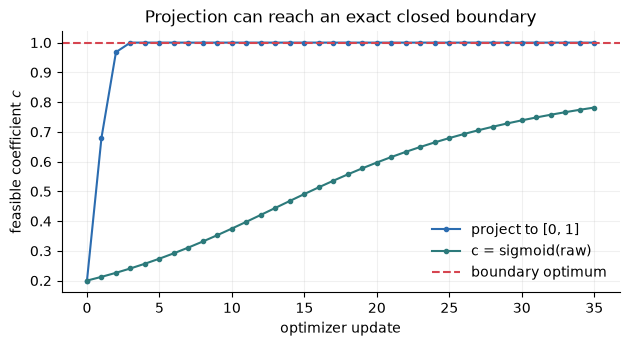

projected final c=1.000000
sigmoid final c=0.781698


In [24]:
eta_project, projection_steps = .40, 35

projected_c = torch.nn.Parameter(torch.tensor(.20))
projected_opt = torch.optim.SGD([projected_c], lr=eta_project)
projected_path = [projected_c.item()]

raw_box = torch.nn.Parameter(torch.logit(torch.tensor(.20)))
raw_box_opt = torch.optim.SGD([raw_box], lr=eta_project)
sigmoid_path = [raw_box.sigmoid().item()]

for _ in range(projection_steps):
    projected_opt.zero_grad(set_to_none=True)
    (.5 * (projected_c - 1.4).square()).backward()
    projected_opt.step()
    with torch.no_grad():
        projected_c.clamp_(min=0, max=1)  # project after optimizer.step()
    projected_path.append(projected_c.item())

    raw_box_opt.zero_grad(set_to_none=True)
    feasible_c = raw_box.sigmoid()
    (.5 * (feasible_c - 1.4).square()).backward()
    raw_box_opt.step()
    sigmoid_path.append(raw_box.sigmoid().item())

plt.plot(projected_path, 'o-', ms=3, color=BLUE, label='project to [0, 1]')
plt.plot(sigmoid_path, 'o-', ms=3, color=TEAL, label='c = sigmoid(raw)')
plt.axhline(1, color=RED, ls='--', label='boundary optimum')
plt.xlabel('optimizer update'); plt.ylabel('feasible coefficient $c$')
plt.title('Projection can reach an exact closed boundary')
plt.legend(frameon=False); plt.show()

print(f'projected final c={projected_path[-1]:.6f}')
print(f'sigmoid final c={sigmoid_path[-1]:.6f}')
assert projected_path[-1] == 1.0
assert 0 < sigmoid_path[-1] < 1


### Minimal projected-gradient pattern

Clamp after the optimizer step and outside autograd:

```python
loss.backward()
optimizer.step()
with torch.no_grad():
    parameter.clamp_(min=a, max=b)  # or clamp_(min=0)
```

Projection is easy for a scalar interval or independent box—both are closed convex sets with a unique nearest-point projection. Projection onto a simplex or a more complicated feasible set requires a dedicated algorithm, so a softmax reparameterization is usually the clearer starting point.

With momentum or Adam, projection changes the parameter but does **not** erase the optimizer's stored state. If projection is active frequently, monitor whether that state repeatedly pushes out of the feasible set.


## Takeaways

1. RMSProp tracks $\boldsymbol v_t$ (PyTorch's internal `square_avg`); Adam tracks $\boldsymbol m_t$ and $\boldsymbol v_t$ (`exp_avg` and `exp_avg_sq`). We checked the complete parameter and state histories against our recurrences.
2. A zero-start EWMA has visible weight mass $1-\beta^k$ after $k$ measurements. Standard momentum keeps that early buildup; Adam corrects both moment estimates before combining them.
3. A schedule changes the scalar $\eta_t$ around any optimizer. Decay directly reduces late stochastic motion; the schedule clock advances only after an executed `optimizer.step()`.
4. Constraints come from parameter meaning. Rebuild feasible values inside every forward pass so autograd differentiates through the transform.
5. For Gaussian noise, learn $a=\log\sigma$ and use $\sigma=\exp(a)>0$; `softplus` is another positive map. The same construction works whether one scale is shared or a network predicts a scale for each input.
6. Use $a+(b-a)\operatorname{sigmoid}(r)$ for an open box, logits with `BCEWithLogitsLoss` for Bernoulli models, and `softmax`/`log_softmax` for simplex weights.
7. Projection is clearest for simple closed convex sets whose boundary is meaningful. Apply it after `optimizer.step()` under `no_grad`; remember that optimizer state is not projected automatically.
